# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [14]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

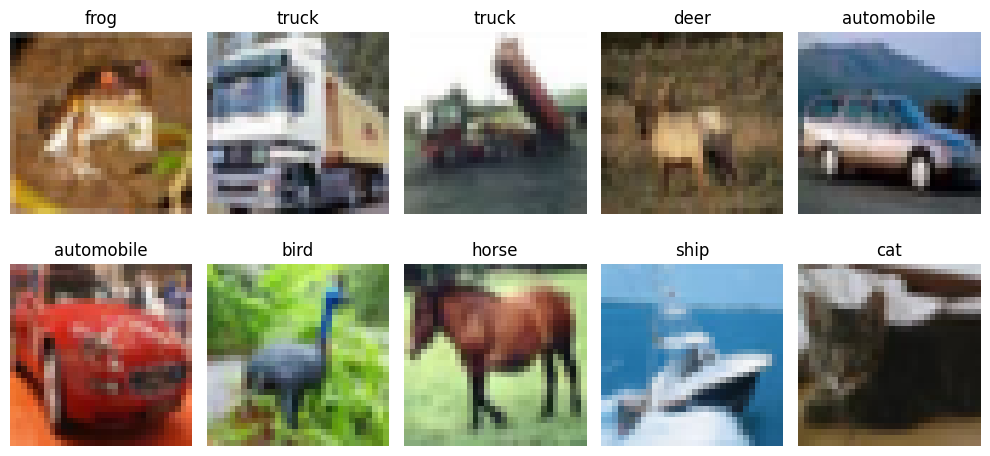

In [15]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [16]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [17]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2672 - loss: 2.0021 - val_accuracy: 0.3444 - val_loss: 1.8625
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3178 - loss: 1.8668 - val_accuracy: 0.3784 - val_loss: 1.7603
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3388 - loss: 1.8130 - val_accuracy: 0.3794 - val_loss: 1.7371
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3513 - loss: 1.7792 - val_accuracy: 0.3944 - val_loss: 1.7289
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3586 - loss: 1.7590 - val_accuracy: 0.3962 - val_loss: 1.7067
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3670 - loss: 1.7376 - val_accuracy: 0.4000 - val_loss: 1.6936
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3735 - loss: 1.7284 - val_accuracy: 0.4024 - val_loss: 1.6827
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3816 - loss: 1.7098 - val_accuracy: 0.

In [20]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4287 - loss: 1.6469
ANN Test Accuracy: 0.4287000000476837


### Task 1: Increase ANN Layers

In [21]:
deep_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deep_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_history = deep_ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.2390 - loss: 2.0467 - val_accuracy: 0.2816 - val_loss: 1.9320
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2990 - loss: 1.9035 - val_accuracy: 0.3368 - val_loss: 1.8505
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3194 - loss: 1.8533 - val_accuracy: 0.3490 - val_loss: 1.8196
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3338 - loss: 1.8211 - val_accuracy: 0.3816 - val_loss: 1.7292
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3469 - loss: 1.7951 - val_accuracy: 0.3866 - val_loss: 1.7420
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3561 - loss: 1.7796 - val_accuracy: 0.3392 - val_loss: 1.8052
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3651 - loss: 1.7538 - val_accuracy: 0.3906 - val_loss: 1.7022
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3661 - loss: 1.7491 - val_accuracy: 0

In [22]:
deep_ann_test_loss, deep_ann_test_acc = deep_ann_model.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", deep_ann_test_acc)
print("Baseline ANN Test Accuracy:", ann_test_acc)
print("Improvement:", deep_ann_test_acc - ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4172 - loss: 1.6607
Deeper ANN Test Accuracy: 0.4171999990940094
Baseline ANN Test Accuracy: 0.4287000000476837
Improvement: -0.011500000953674316


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [23]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4674 - loss: 1.4938 - val_accuracy: 0.5092 - val_loss: 1.3977
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6045 - loss: 1.1298 - val_accuracy: 0.6044 - val_loss: 1.1120
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6708 - loss: 0.9418 - val_accuracy: 0.6624 - val_loss: 1.0106
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7102 - loss: 0.8261 - val_accuracy: 0.5792 - val_loss: 1.2179
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7434 - loss: 0.7325 - val_accuracy: 0.7380 - val_loss: 0.7801
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7692 - loss: 0.6557 - val_accuracy: 0.6894 - val_loss: 0.9256
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7935 - loss: 0.5831 - val_accuracy: 0.7030 - val_loss: 0.9830
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8161 - loss: 0.5225 - val_accuracy: 

In [24]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7238 - loss: 0.9308
CNN Test Accuracy: 0.723800003528595


## 📈 Compare Learning Curves

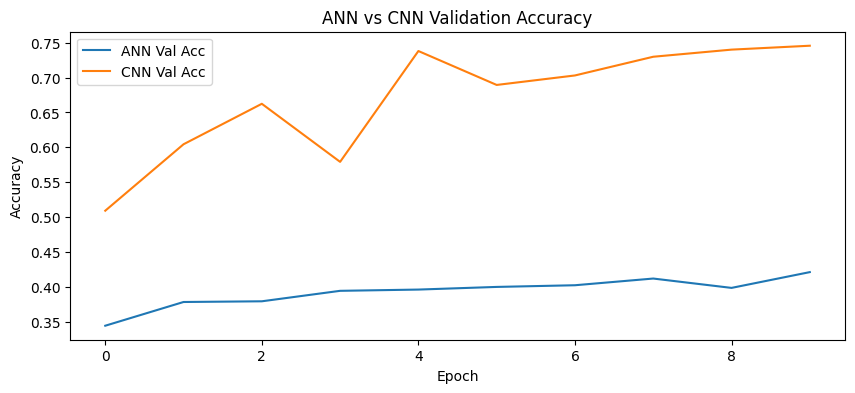

In [25]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

### Task 3 & 4: Increase Epochs to 20 + Add EarlyStopping

In [30]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_model_v2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_v2_history = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4689 - loss: 1.4893 - val_accuracy: 0.5344 - val_loss: 1.2851
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6053 - loss: 1.1242 - val_accuracy: 0.5322 - val_loss: 1.3700
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6685 - loss: 0.9549 - val_accuracy: 0.6128 - val_loss: 1.1582
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7102 - loss: 0.8312 - val_accuracy: 0.6812 - val_loss: 0.9151
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7412 - loss: 0.7381 - val_accuracy: 0.6854 - val_loss: 0.9260
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7645 - loss: 0.6662 - val_accuracy: 0.6716 - val_loss: 0.9470
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7888 - loss: 0.5998 - val_accuracy: 0.6606 - val_loss: 1.0419


In [31]:
cnn_v2_test_loss, cnn_v2_test_acc = cnn_model_v2.evaluate(x_test_norm, y_test)
print("CNN (20 epochs + EarlyStopping) Test Accuracy:", cnn_v2_test_acc)
print("Stopped at epoch:", len(cnn_v2_history.history['loss']), "of 20")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6734 - loss: 0.9359
CNN (20 epochs + EarlyStopping) Test Accuracy: 0.6733999848365784
Stopped at epoch: 7 of 20


### Task 5: Add Data Augmentation Training

In [32]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3506 - loss: 1.7686 - val_accuracy: 0.4788 - val_loss: 1.4359
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4557 - loss: 1.5162 - val_accuracy: 0.4990 - val_loss: 1.3664
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4911 - loss: 1.4200 - val_accuracy: 0.5724 - val_loss: 1.1943
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5203 - loss: 1.3532 - val_accuracy: 0.5858 - val_loss: 1.1664
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5372 - loss: 1.3080 - val_accuracy: 0.5848 - val_loss: 1.1554
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5464 - loss: 1.2748 - val_accuracy: 0.5896 - val_loss: 1.1765
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5569 - loss: 1.2516 - val_accuracy: 0.6358 - val_loss: 1.0372
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5698 - loss: 1.2231 - val_accuracy: 0

In [33]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)
print("Stopped at epoch:", len(aug_history.history['loss']), "of 20")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6471 - loss: 1.0062
Augmented CNN Test Accuracy: 0.6470999717712402
Stopped at epoch: 16 of 20


# 📊 Final Comparison Table

In [34]:
results = pd.DataFrame({
    "Model": [
        "ANN (baseline)",
        "ANN (deeper)",
        "CNN (baseline, 10 epochs)",
        "CNN (20 epochs + EarlyStopping)",
        "CNN + Data Augmentation"
    ],
    "Key Technique": [
        "Flattened input, 2 dense layers",
        "More/larger dense layers",
        "Conv2D filters 32→64→128, BatchNorm",
        "Longer training, stops automatically",
        "Random flip/rotate/zoom during training"
    ],
    "Test Accuracy": [
        ann_test_acc,
        deep_ann_test_acc,
        cnn_test_acc,
        cnn_v2_test_acc,
        aug_test_acc
    ]
})

results["Test Accuracy"] = results["Test Accuracy"].round(4)
results

,Model,Key Technique,Test Accuracy
0,ANN (baseline),"Flattened input, 2 dense layers",0.4287
1,ANN (deeper),More/larger dense layers,0.4172
2,"CNN (baseline, 10 epochs)","Conv2D filters 32→64→128, BatchNorm",0.7238
3,CNN (20 epochs + EarlyStopping),"Longer training, stops automatically",0.6734
4,CNN + Data Augmentation,Random flip/rotate/zoom during training,0.6471


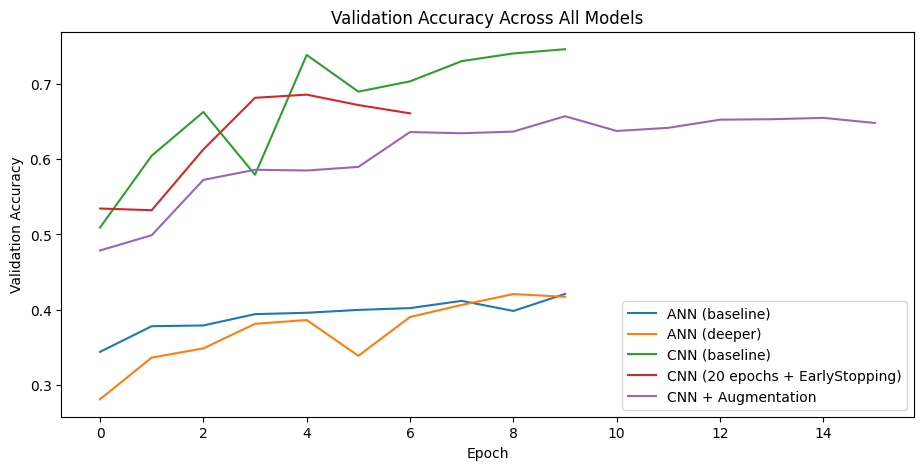

In [35]:
plt.figure(figsize=(11,5))
plt.plot(ann_history.history['val_accuracy'], label='ANN (baseline)')
plt.plot(deep_ann_history.history['val_accuracy'], label='ANN (deeper)')
plt.plot(cnn_history.history['val_accuracy'], label='CNN (baseline)')
plt.plot(cnn_v2_history.history['val_accuracy'], label='CNN (20 epochs + EarlyStopping)')
plt.plot(aug_history.history['val_accuracy'], label='CNN + Augmentation')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across All Models")
plt.legend()
plt.show()

### Conclusion
- ANN works, but ignores image structure — making it **deeper alone doesn't close the
  gap** with CNN, since it still only ever sees a flat vector of pixels.
- CNN extracts spatial features through convolution + pooling, so it performs
  significantly better with far fewer dense parameters.
- Doubling filters (32→64→128) lets the CNN learn increasingly abstract features as it
  goes deeper.
- **EarlyStopping** lets us safely train for more epochs (20) without wasting compute
  or overfitting — training stops as soon as validation loss stops improving, and the
  best weights are restored automatically.
- **Data augmentation** (flips, rotations, zooms) exposes the model to more visual
  variety, typically improving generalization to the held-out test set.
- Together, these training strategies (dropout, batch norm, EarlyStopping,
  augmentation) are what separate a basic CNN from a production-ready one.

This project builds strong fundamentals for computer vision interviews and deep
learning projects.